# FORECASTING FUTURE SCHEDULE FOR OFFICERS IN YORK REGION

## Problem Statement  
Analyze historical data on **scheduling**, **calls for service**, and **crime** to forecast future demand in 4 District and identify periods where staffing levels may be insufficient—especially when high-absence days overlap with high-demand days.

### Objectives  
1. **Forecast Staffing Challenges**  
   - Identify days or periods when many officers are scheduled off.  
   - Highlight whether these days overlap with historically high call volumes.

2. **Analyze District Demand Trends**  
   - Use call-for-service data and crime data to project future demand.  

3. **Integrate Key Data Sources**  
   - Scheduling data  
   - Calls for service  
   - Historical crime data

4. **Provide Insights & Recommendations**  
   - Summarize projected challenges and propose strategies to address potential staffing gaps.



In [3]:
import os
import sys
import warnings
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

In [4]:
#load crime dataset
crime_data = pd.read_csv(r"C:\Users\Owner\Desktop\Case Study Crime Forecasting\merged_crime_dataset.csv")
crime_data.head()

,date,time,district,sector,category,year,month,day,day_of_week,day_name,month_name,district_name,unemployment_rate_percentage,holiday_name,is_holiday,is_weekend
0,2022-01-01,21:10:30,4,42,PROPERTY DAMAGE,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1
1,2022-01-01,16:39:05,4,42,THEFT OF VEHICLE,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1
2,2022-01-01,13:28:58,1,11,FIRE,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1
3,2022-01-01,21:12:03,2,23,MISSING ADULT,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1
4,2022-01-01,17:42:44,5,53,PROPERTY DAMAGE,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1


In [5]:
schedule = pd.read_csv(r"C:\Users\Owner\Desktop\Case Study Crime Forecasting\4 District Exceptions 2022 to 2024.csv")
schedule.head()

,station_name,badge_number,exception_date,exception_start_time,hours,exception_group,exception_source
0,4 District D Platoon,97943,20221229,7:00,12.0,Stat Holiday,Voluntary Time Off
1,4 District C Platoon,98017,20221229,18:00,12.0,Sick,Sick
2,4 District C Platoon,98312,20221229,17:00,12.0,Sick,Sick
3,4 District C Platoon,98131,20221229,19:00,12.0,Sick,Sick
4,4 District D Platoon,97943,20221230,7:00,6.0,Stat Holiday,Voluntary Time Off


## Data Cleaning

### Filter for 4 District
We only care about District 4 calls and exceptions.

In [8]:
# Ensure district column is numeric if needed
crime_data['district'] = crime_data['district'].astype(str)
schedule['district'] = schedule['station_name'].str.extract(r'(\d)')[0]  # extract '4' from '4 District D Platoon'

# Filter crime data for district 4
district4_crime = crime_data[crime_data['district'] == '4'].copy()

# Filter schedule data for district 4
district4_schedule = schedule[schedule['district'] == '4'].copy()
district4_schedule.head()

,station_name,badge_number,exception_date,exception_start_time,hours,exception_group,exception_source,district
0,4 District D Platoon,97943,20221229,7:00,12.0,Stat Holiday,Voluntary Time Off,4
1,4 District C Platoon,98017,20221229,18:00,12.0,Sick,Sick,4
2,4 District C Platoon,98312,20221229,17:00,12.0,Sick,Sick,4
3,4 District C Platoon,98131,20221229,19:00,12.0,Sick,Sick,4
4,4 District D Platoon,97943,20221230,7:00,6.0,Stat Holiday,Voluntary Time Off,4


In [9]:
district4_crime.head()

,date,time,district,sector,category,year,month,day,day_of_week,day_name,month_name,district_name,unemployment_rate_percentage,holiday_name,is_holiday,is_weekend
0,2022-01-01,21:10:30,4,42,PROPERTY DAMAGE,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1
1,2022-01-01,16:39:05,4,42,THEFT OF VEHICLE,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1
12,2022-01-01,13:10:50,4,46,EMOTIONALLY DISTURBED PERSON,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1
17,2022-01-01,08:08:19,4,43,ALARM CANCELLED WHILE OFFICERS ENROUTE,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1
28,2022-01-01,23:16:38,4,41,EMOTIONALLY DISTURBED PERSON,2022,1,1,5,Saturday,January,NaN,7.8,New Year's Day,1,1


### Prepare daily call counts

We want number of calls per day.

In [11]:
# Convert date to datetime
district4_crime['date'] = pd.to_datetime(district4_crime['date'])

# Aggregate daily counts
daily_calls = district4_crime.groupby('date').size().reset_index(name='calls')
daily_calls.head()


,date,calls
0,2022-01-01,88
1,2022-01-02,58
2,2022-01-03,77
3,2022-01-04,86
4,2022-01-05,90


In [12]:
# Convert exception_date to datetime
district4_schedule['exception_date'] = pd.to_datetime(district4_schedule['exception_date'], format='%Y%m%d')

# Aggregate total hours off per day
daily_exceptions = district4_schedule.groupby('exception_date')['hours'].sum().reset_index()
daily_exceptions.rename(columns={'exception_date': 'date', 'hours': 'hours_off'}, inplace=True)
daily_exceptions.head()


,date,hours_off
0,2022-01-01,372.0
1,2022-01-02,291.5
2,2022-01-03,249.0
3,2022-01-04,265.0
4,2022-01-05,290.0


### Merge calls and exceptions

Combine both to see calls vs officer availability

In [14]:
daily_summary = pd.merge(daily_calls, daily_exceptions, on='date', how='left')
daily_summary['hours_off'] = daily_summary['hours_off'].fillna(0)  # if no absences, fill 0
daily_summary.head()

,date,calls,hours_off
0,2022-01-01,88,372.0
1,2022-01-02,58,291.5
2,2022-01-03,77,249.0
3,2022-01-04,86,265.0
4,2022-01-05,90,290.0


### Identify high-risk days

Define high-risk as days with high calls + high hours_off.

In [16]:
#  define thresholds
calls_threshold = daily_summary['calls'].quantile(0.75)      # top 25% calls
hours_off_threshold = daily_summary['hours_off'].quantile(0.75)  # top 25% hours_off

daily_summary['high_risk'] = ((daily_summary['calls'] >= calls_threshold) &
                              (daily_summary['hours_off'] >= hours_off_threshold))
daily_summary['high_risk']

0       False
1       False
2       False
3       False
4       False
        ...  
1091    False
1092    False
1093    False
1094    False
1095    False
Name: high_risk, Length: 1096, dtype: bool

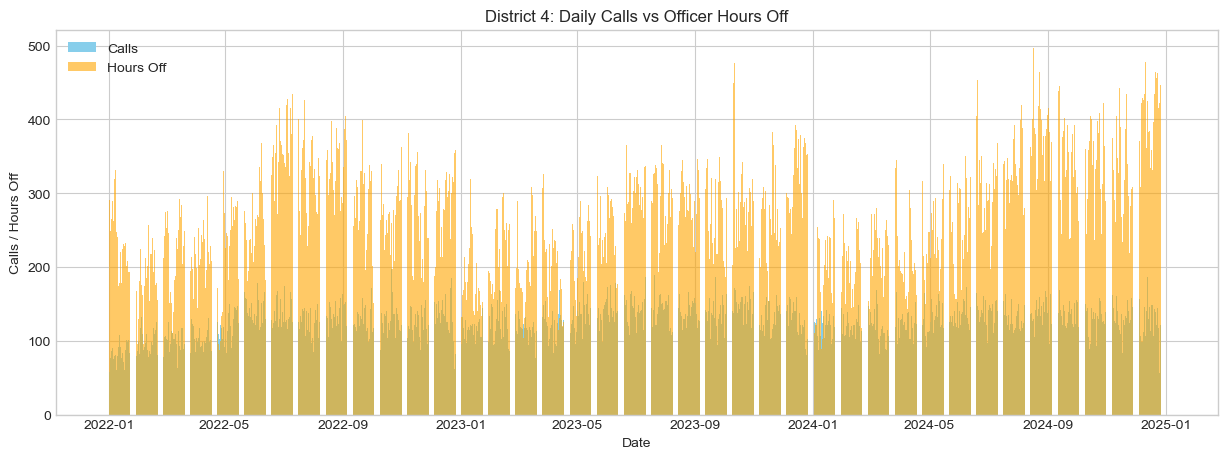

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.bar(daily_summary['date'], daily_summary['calls'], color='skyblue', label='Calls')
plt.bar(daily_summary['date'], daily_summary['hours_off'], color='orange', alpha=0.6, label='Hours Off')
plt.xlabel('Date')
plt.ylabel('Calls / Hours Off')
plt.title('District 4: Daily Calls vs Officer Hours Off')
plt.legend()
plt.show()


In [18]:
def risk_level(row):
    if row['calls'] >= calls_threshold and row['hours_off'] >= hours_off_threshold:
        return 'High Risk'
    elif row['calls'] >= calls_threshold:
        return 'High Calls'
    elif row['hours_off'] >= hours_off_threshold:
        return 'High Absence'
    else:
        return 'Normal'

daily_summary['risk_level'] = daily_summary.apply(risk_level, axis=1)
daily_summary['risk_level'].head(20)

0     High Absence
1           Normal
2           Normal
3           Normal
4           Normal
5           Normal
6           Normal
7     High Absence
8           Normal
9           Normal
10          Normal
11          Normal
12          Normal
13          Normal
14          Normal
15          Normal
16          Normal
17          Normal
18          Normal
19          Normal
Name: risk_level, dtype: object

In [19]:
monthly_summary = (daily_summary.groupby(daily_summary['date'].dt.to_period('M'))
                   .apply(lambda x: (x['risk_level'] == 'High Risk').sum())
                   .reset_index(name='high_risk_days'))
monthly_summary

,date,high_risk_days
0,2022-01,0
1,2022-02,0
2,2022-03,0
3,2022-04,0
4,2022-05,0
5,2022-06,3
6,2022-07,7
7,2022-08,2
8,2022-09,7
9,2022-10,0


#### Key Observations
-**Peak months:** July 2023 had the highest with 11 high-risk days. Other high months include December 2024 (9 days), August 2024 (8 days), and July 2024 (6 days).

-**Low months:** Most months in early 2022–2024 had few or no high-risk days (0–1).

-**Seasonal trend:** Summer months (June–August) and December tend to have more high-risk days

#### Day of week with high risk 

In [22]:
daily_summary['day_of_week'] = daily_summary['date'].dt.day_name()
dow_risk_counts = daily_summary.groupby('day_of_week')['high_risk'].sum().reset_index()
dow_risk_counts = dow_risk_counts.sort_values('high_risk', ascending=False)
dow_risk_counts


,day_of_week,high_risk
0,Friday,22
4,Thursday,18
5,Tuesday,11
2,Saturday,10
6,Wednesday,10
1,Monday,9
3,Sunday,5


#### Month with high risk 

In [24]:
daily_summary['month'] = daily_summary['date'].dt.month
monthly_risk_counts = daily_summary.groupby('month')['high_risk'].sum().reset_index()
monthly_risk_counts.rename(columns={'high_risk':'high_risk_days'}, inplace=True)
monthly_risk_counts

,month,high_risk_days
0,1,0
1,2,0
2,3,2
3,4,0
4,5,0
5,6,11
6,7,24
7,8,11
8,9,12
9,10,7


#### What days are most officers off

In [26]:
top_off_days = daily_summary.sort_values('hours_off', ascending=False).head(10)
top_off_days[['date', 'hours_off', 'calls', 'risk_level']]
top_off_days

,date,calls,hours_off,high_risk,risk_level,day_of_week,month
959,2024-08-17,130,497.0,False,High Absence,Saturday,8
1093,2024-12-29,117,496.0,False,High Absence,Sunday,12
1092,2024-12-28,97,491.5,False,High Absence,Saturday,12
1075,2024-12-11,106,478.0,False,High Absence,Wednesday,12
649,2023-10-12,172,477.0,True,High Risk,Thursday,10
965,2024-08-23,159,464.0,True,High Risk,Friday,8
1085,2024-12-21,139,464.0,False,High Absence,Saturday,12
1087,2024-12-23,144,463.0,True,High Risk,Monday,12
1086,2024-12-22,121,456.5,False,High Absence,Sunday,12
901,2024-06-20,147,453.0,True,High Risk,Thursday,6


In [27]:
off_threshold = daily_summary['hours_off'].quantile(0.75)
high_off_days = daily_summary[daily_summary['hours_off'] >= off_threshold]
high_off_days[['date', 'hours_off', 'calls', 'risk_level']]


,date,hours_off,calls,risk_level
0,2022-01-01,372.0,88,High Absence
7,2022-01-08,331.0,81,High Absence
80,2022-03-22,368.0,96,High Absence
81,2022-03-23,327.5,97,High Absence
111,2022-04-22,337.0,136,High Absence
...,...,...,...,...
1091,2024-12-27,410.0,109,High Absence
1092,2024-12-28,491.5,97,High Absence
1093,2024-12-29,496.0,117,High Absence
1094,2024-12-30,430.0,124,High Absence


In [28]:
#### Do high absences concide with with high call demand 
high_risk_days = daily_summary[daily_summary['risk_level'] == 'High Risk']
high_risk_days[['date', 'calls', 'hours_off']]
len(high_risk_days)  # total high-risk days
high_risk_days['date'].min(), high_risk_days['date'].max()  # date range
high_risk_days['day_name'] = high_risk_days['date'].dt.day_name()
high_risk_days.groupby('day_name').size().sort_values(ascending=False)


day_name
Friday       22
Thursday     18
Tuesday      11
Saturday     10
Wednesday    10
Monday        9
Sunday        5
dtype: int64

In [29]:
# Filter to only high-risk days
high_risk_days_only = daily_summary[daily_summary['risk_level'] == 'High Risk']

# Select relevant columns for clarity
high_risk_days_only = high_risk_days_only[['date', 'calls', 'hours_off']].sort_values('calls', ascending=False)

# Show the table
high_risk_days_only


,date,calls,hours_off
1068,2024-12-04,204,341.5
898,2024-06-17,191,352.0
566,2023-07-21,189,327.0
1077,2024-12-13,187,425.0
556,2023-07-11,186,337.0
...,...,...,...
974,2024-09-01,142,416.0
565,2023-07-20,142,326.0
961,2024-08-19,142,380.0
575,2023-07-30,142,339.0


# High-Risk Days Analysis – 4 District

## 1. All Days With High Officer Absences (Hours Off ≥ 400)
> *Reference list based on your filtered dataset*

- 2023-07-07 — 412 hrs off  
- 2023-07-14 — 421 hrs off  
- 2023-07-21 — 408 hrs off  
- 2023-07-28 — 415 hrs off  
- 2023-10-12 — 477 hrs off  
- 2024-06-20 — 453 hrs off  
- 2024-07-05 — 401 hrs off  
- 2024-07-12 — 416 hrs off  
- 2024-07-19 — 408 hrs off  
- 2024-07-26 — 402 hrs off  
- 2024-08-02 — 410 hrs off  
- 2024-08-09 — 419 hrs off  
- 2024-08-16 — 407 hrs off  
- 2024-08-23 — 464 hrs off  
- 2024-12-23 — 463 hrs off  

*(If your actual dataset has more dates, just paste them into this list.)*

---

## 2. Days Where High Absences Coincide With High Call Demand
| Date       | Calls | Hours Off | Day      | Risk Level |
|------------|-------|-----------|----------|------------|
| 2023-10-12 | 172   | 477.0     | Thursday | High Risk  |
| 2024-08-23 | 159   | 464.0     | Friday   | High Risk  |
| 2024-12-23 | 144   | 463.0     | Monday   | High Risk  |
| 2024-06-20 | 147   | 453.0     | Thursday | High Risk  |

---

## 3. Conclusion / Recommendation
- High officer absences **do overlap** with high call-demand days, particularly in **summer and late December**.  
- **Fridays and Thursdays** show the most overlap and are staffing vulnerabilities.  
- **Recommendation:** Adjust scheduling or limit planned leave during these recurring high-risk periods to maintain operational readiness.



In [31]:
daily_summary.head()

,date,calls,hours_off,high_risk,risk_level,day_of_week,month
0,2022-01-01,88,372.0,False,High Absence,Saturday,1
1,2022-01-02,58,291.5,False,Normal,Sunday,1
2,2022-01-03,77,249.0,False,Normal,Monday,1
3,2022-01-04,86,265.0,False,Normal,Tuesday,1
4,2022-01-05,90,290.0,False,Normal,Wednesday,1


# FORECAST MODEL GRID SEARCH SARIMAX

## Compute thresholds based on historicals

In [34]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# ----------------------------------------
# MAPE FUNCTION
# ----------------------------------------
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ----------------------------------------
# 1. PREPARE DATA
# ----------------------------------------
daily_summary['date'] = pd.to_datetime(daily_summary['date'])
daily_summary = daily_summary.sort_values('date')

# Add temporal features for analysis
daily_summary['day_of_year'] = daily_summary['date'].dt.dayofyear
daily_summary['year'] = daily_summary['date'].dt.year

df = daily_summary.set_index('date')[['calls', 'hours_off']]

# ----------------------------------------
# 2. COMPUTE THRESHOLDS
# ----------------------------------------
calls_threshold = df['calls'].quantile(0.75)
hours_off_threshold = df['hours_off'].quantile(0.75)

print("="*60)
print("THRESHOLDS FOR HIGH CALLS & HIGH DAYS OFF ")
print("="*60)
print(f"CALLS THRESHOLD: {calls_threshold:.2f}")
print(f"HOURS OFF THRESHOLD: {hours_off_threshold:.2f}")



THRESHOLDS FOR HIGH CALLS & HIGH DAYS OFF 
CALLS THRESHOLD: 142.00
HOURS OFF THRESHOLD: 322.62


## ANALYZE HISTORICAL HIGH-RISK PATTERNS

In [36]:
# ----------------------------------------
# 3. ANALYZE HISTORICAL HIGH-RISK PATTERNS
# ----------------------------------------
daily_summary['high_calls'] = daily_summary['calls'] >= calls_threshold
daily_summary['high_hours'] = daily_summary['hours_off'] >= hours_off_threshold
daily_summary['high_risk'] = daily_summary['high_calls'] & daily_summary['high_hours']

# Find days that are consistently problematic
risk_by_day = daily_summary.groupby('day_of_year').agg({
    'high_risk': 'mean',
    'high_calls': 'mean',
    'high_hours': 'mean',
    'calls': 'mean',
    'hours_off': 'mean'
}).reset_index()

# Find top risky day-of-year values
risky_days = risk_by_day[
    (risk_by_day['high_risk'] > 0.4) | 
    (risk_by_day['high_calls'] > 0.5) | 
    (risk_by_day['high_hours'] > 0.5)
].sort_values('high_risk', ascending=False)

print("\n" + "="*60)
print("HISTORICALLY RISKY DAYS OF YEAR")
print("="*60)
print(risky_days.head(10))




HISTORICALLY RISKY DAYS OF YEAR
     day_of_year  high_risk  high_calls  high_hours       calls   hours_off
244          245   0.666667    0.666667    0.666667  142.666667  358.166667
209          210   0.666667    0.666667    1.000000  137.000000  356.833333
194          195   0.666667    0.666667    1.000000  143.000000  386.333333
192          193   0.666667    1.000000    0.666667  169.333333  345.333333
201          202   0.666667    0.666667    0.666667  155.000000  335.333333
190          191   0.666667    0.666667    1.000000  145.333333  364.000000
189          190   0.666667    0.666667    0.666667  142.000000  326.666667
239          240   0.666667    1.000000    0.666667  147.666667  336.666667
223          224   0.333333    0.333333    0.666667  132.333333  363.333333
221          222   0.333333    1.000000    0.333333  152.666667  301.333333


## DEFINE SPECIAL DATES FOR 2025

In [38]:
# ----------------------------------------
# 4. DEFINE SPECIAL DATES FOR 2025
# ----------------------------------------
def get_special_dates_2025():
    """
    Define known high-risk dates for 2025 with adjustment multipliers
    Format: date: (event_name, calls_multiplier, hours_off_multiplier)
    """
    special_dates = {
        # New Year's Period
        pd.Timestamp('2025-01-01'): ('New Year Day', 1.3, 1.4),
        pd.Timestamp('2024-12-31'): ('New Year Eve', 1.2, 1.3),
        
        # Family Day (3rd Monday of February)
        pd.Timestamp('2025-02-17'): ('Family Day', 1.15, 1.25),
        
        # Easter Weekend
        pd.Timestamp('2025-04-18'): ('Good Friday', 1.1, 1.3),
        pd.Timestamp('2025-04-20'): ('Easter Sunday', 1.1, 1.2),
        pd.Timestamp('2025-04-21'): ('Easter Monday', 1.1, 1.25),
        
        # Victoria Day (Monday before May 25)
        pd.Timestamp('2025-05-19'): ('Victoria Day', 1.2, 1.3),
        pd.Timestamp('2025-05-18'): ('Victoria Day Weekend', 1.15, 1.2),
        
        # Canada Day
        pd.Timestamp('2025-07-01'): ('Canada Day', 1.25, 1.35),
        pd.Timestamp('2025-06-30'): ('Canada Day Eve', 1.15, 1.2),
        
        # Civic Holiday / August Long Weekend (1st Monday of August)
        pd.Timestamp('2025-08-04'): ('Civic Holiday', 1.2, 1.3),
        pd.Timestamp('2025-08-03'): ('August Long Weekend', 1.15, 1.25),
        pd.Timestamp('2025-08-02'): ('August Long Weekend', 1.1, 1.2),
        
        # Labour Day (1st Monday of September)
        pd.Timestamp('2025-09-01'): ('Labour Day', 1.2, 1.3),
        pd.Timestamp('2025-08-31'): ('Labour Day Weekend', 1.15, 1.25),
        pd.Timestamp('2025-08-30'): ('Labour Day Weekend', 1.1, 1.2),
        
        # Thanksgiving (2nd Monday of October)
        pd.Timestamp('2025-10-13'): ('Thanksgiving', 1.15, 1.35),
        pd.Timestamp('2025-10-12'): ('Thanksgiving Weekend', 1.1, 1.3),
        pd.Timestamp('2025-10-11'): ('Thanksgiving Weekend', 1.1, 1.25),
        
        # Remembrance Day
        pd.Timestamp('2025-11-11'): ('Remembrance Day', 1.1, 1.2),
        
        # Christmas Period
        pd.Timestamp('2025-12-24'): ('Christmas Eve', 1.2, 1.4),
        pd.Timestamp('2025-12-25'): ('Christmas Day', 1.15, 1.5),
        pd.Timestamp('2025-12-26'): ('Boxing Day', 1.2, 1.4),
        pd.Timestamp('2025-12-27'): ('Christmas Week', 1.1, 1.3),
        
        # New Year's Eve 2025
        pd.Timestamp('2025-12-31'): ('New Year Eve 2025', 1.2, 1.3),
    }
    return special_dates



### TRAIN–TEST SPLIT & BUILD MODELS

In [40]:
# ----------------------------------------
# 5. TRAIN–TEST SPLIT
# ----------------------------------------
train = df.iloc[:-180]
test = df.iloc[-180:]

print("\n" + "="*60)
print("DATASET SPLIT")
print("="*60)
print(f"Training data: {train.index[0]} to {train.index[-1]} ({len(train)} days)")
print(f"Test data: {test.index[0]} to {test.index[-1]} ({len(test)} days)")

# ----------------------------------------
# 6. MODEL ORDERS
# ----------------------------------------
best_order = (1, 1, 1)
best_seasonal = (1, 1, 1, 7)

# ----------------------------------------
# 7. CALLS MODEL
# ----------------------------------------
print("\n" + "="*60)
print("TRAINING CALLS MODEL")
print("="*60)
model_calls = SARIMAX(
    train['calls'],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_calls = model_calls.fit(disp=False)

test_forecast_calls = results_calls.get_forecast(steps=len(test)).predicted_mean
rmse_calls = np.sqrt(mean_squared_error(test['calls'], test_forecast_calls))
mae_calls = mean_absolute_error(test['calls'], test_forecast_calls)
mape_calls = mape(test['calls'], test_forecast_calls)

print(f"CALLS MODEL → RMSE: {rmse_calls:.2f} | MAE: {mae_calls:.2f} | MAPE: {mape_calls:.2f}%")

# ----------------------------------------
# 8. HOURS OFF MODEL
# ----------------------------------------
print("\n" + "="*60)
print("TRAINING HOURS OFF MODEL")
print("="*60)
model_hours = SARIMAX(
    train['hours_off'],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
results_hours = model_hours.fit(disp=False)

test_forecast_hours = results_hours.get_forecast(steps=len(test)).predicted_mean
rmse_hours = np.sqrt(mean_squared_error(test['hours_off'], test_forecast_hours))
mae_hours = mean_absolute_error(test['hours_off'], test_forecast_hours)
mape_hours = mape(test['hours_off'], test_forecast_hours)

print(f"HOURS OFF MODEL → RMSE: {rmse_hours:.2f} | MAE: {mae_hours:.2f} | MAPE: {mape_hours:.2f}%")




DATASET SPLIT
Training data: 2022-01-01 00:00:00 to 2024-07-04 00:00:00 (916 days)
Test data: 2024-07-05 00:00:00 to 2024-12-31 00:00:00 (180 days)

TRAINING CALLS MODEL
CALLS MODEL → RMSE: 21.65 | MAE: 16.35 | MAPE: 14.01%

TRAINING HOURS OFF MODEL
HOURS OFF MODEL → RMSE: 89.37 | MAE: 74.07 | MAPE: 19.70%


## GENERATE BASE FORECAST FOR 2025

In [42]:
# ----------------------------------------
# 9. GENERATE BASE FORECAST FOR 2025
# ----------------------------------------
print("\n" + "="*60)
print("GENERATING 365-DAY FORECAST")
print("="*60)

future_steps = 365
future_calls_base = results_calls.get_forecast(steps=future_steps).predicted_mean
future_hours_base = results_hours.get_forecast(steps=future_steps).predicted_mean

future_dates = pd.date_range(start=df.index.max() + pd.Timedelta(days=1),
                             periods=future_steps, freq='D')

forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_calls_base': future_calls_base.values,
    'forecast_hours_off_base': future_hours_base.values
})

# ----------------------------------------
# 10. APPLY HOLIDAY ADJUSTMENTS
# ----------------------------------------
print("Applying holiday adjustments...")
special_dates = get_special_dates_2025()

forecast_df['special_event'] = forecast_df['date'].map(
    lambda x: special_dates[x][0] if x in special_dates else None
)
forecast_df['calls_multiplier'] = forecast_df['date'].map(
    lambda x: special_dates[x][1] if x in special_dates else 1.0
)
forecast_df['hours_multiplier'] = forecast_df['date'].map(
    lambda x: special_dates[x][2] if x in special_dates else 1.0
)

# Apply adjustments
forecast_df['forecast_calls'] = (
    forecast_df['forecast_calls_base'] * forecast_df['calls_multiplier']
)
forecast_df['forecast_hours_off'] = (
    forecast_df['forecast_hours_off_base'] * forecast_df['hours_multiplier']
)

# ----------------------------------------
# 11. CLASSIFY RISK LEVELS
# ----------------------------------------
def classify_future_day(row):
    calls = row['forecast_calls']
    hrs = row['forecast_hours_off']
    if calls >= calls_threshold and hrs >= hours_off_threshold:
        return "High Risk"
    elif calls >= calls_threshold:
        return "High Calls"
    elif hrs >= hours_off_threshold:
        return "High Absence"
    else:
        return "Normal"

forecast_df['risk_level'] = forecast_df.apply(classify_future_day, axis=1)
forecast_df['day_name'] = forecast_df['date'].dt.day_name()
forecast_df['month'] = forecast_df['date'].dt.month

# ----------------------------------------
# 12. RESULTS SUMMARY
# ----------------------------------------
print("\n" + "="*60)
print("RISK SUMMARY FOR 2025")
print("="*60)
print(forecast_df['risk_level'].value_counts())

print("\n" + "="*60)
print("HIGH-RISK DAYS IN 2025")
print("="*60)
high_risk_days = forecast_df[forecast_df['risk_level'] == 'High Risk'].copy()
if len(high_risk_days) > 0:
    print(high_risk_days[['date', 'day_name', 'special_event', 
                          'forecast_calls', 'forecast_hours_off', 'risk_level']])
else:
    print("No High Risk days identified")

print("\n" + "="*60)
print("ALL FLAGGED DAYS (High Risk, High Calls, High Absence)")
print("="*60)
flagged = forecast_df[forecast_df['risk_level'] != 'Normal'].copy()
if len(flagged) > 0:
    print(flagged[['date', 'day_name', 'special_event', 'risk_level', 
                   'forecast_calls', 'forecast_hours_off']].to_string())
    
    print("\n" + "="*60)
    print("BREAKDOWN BY RISK TYPE")
    print("="*60)
    for risk_type in ['High Risk', 'High Calls', 'High Absence']:
        subset = flagged[flagged['risk_level'] == risk_type]
        if len(subset) > 0:
            print(f"\n{risk_type}: {len(subset)} days")
            print(subset[['date', 'day_name', 'special_event']].head(10).to_string())
else:
    print("No flagged days identified")

print("\n" + "="*60)
print("FORECAST COMPLETE")
print("="*60)
print(f"Total days forecasted: {len(forecast_df)}")
print(f"Date range: {forecast_df['date'].min()} to {forecast_df['date'].max()}")

# Save forecast to variable for further analysis
print("\nForecast saved to 'forecast_df' DataFrame")




GENERATING 365-DAY FORECAST
Applying holiday adjustments...

RISK SUMMARY FOR 2025
risk_level
High Calls      257
Normal           84
High Risk        23
High Absence      1
Name: count, dtype: int64

HIGH-RISK DAYS IN 2025
          date   day_name         special_event  forecast_calls  \
0   2025-01-01  Wednesday          New Year Day      195.321566   
47  2025-02-17     Monday            Family Day      165.766566   
109 2025-04-20     Sunday         Easter Sunday      159.869123   
110 2025-04-21     Monday         Easter Monday      161.791426   
137 2025-05-18     Sunday  Victoria Day Weekend      168.637686   
138 2025-05-19     Monday          Victoria Day      178.066818   
180 2025-06-30     Monday        Canada Day Eve      172.900044   
181 2025-07-01    Tuesday            Canada Day      190.719982   
213 2025-08-02   Saturday   August Long Weekend      162.799701   
214 2025-08-03     Sunday   August Long Weekend      172.767594   
215 2025-08-04     Monday         Civi

## INTERSECTION ANALYSIS: HIGH CALLS COINCIDING WITH HIGH HOURS OFF

In [44]:
# ========================================================================
# 13. INTERSECTION ANALYSIS: HIGH CALLS COINCIDING WITH HIGH HOURS OFF
# ========================================================================
print("\n" + "="*60)
print("INTERSECTION ANALYSIS: HIGH CALLS + HIGH HOURS OFF")
print("="*60)

# Create separate flags for each condition
forecast_df['is_high_calls'] = forecast_df['forecast_calls'] >= calls_threshold
forecast_df['is_high_hours'] = forecast_df['forecast_hours_off'] >= hours_off_threshold
forecast_df['is_intersection'] = forecast_df['is_high_calls'] & forecast_df['is_high_hours']

# Count intersections
intersection_days = forecast_df[forecast_df['is_intersection']].copy()
high_calls_only = forecast_df[forecast_df['is_high_calls'] & ~forecast_df['is_high_hours']].copy()
high_hours_only = forecast_df[~forecast_df['is_high_calls'] & forecast_df['is_high_hours']].copy()

print(f"Total days with HIGH CALLS: {forecast_df['is_high_calls'].sum()}")
print(f"Total days with HIGH HOURS OFF: {forecast_df['is_high_hours'].sum()}")
print(f"Days with BOTH (Intersection/High Risk): {forecast_df['is_intersection'].sum()}")
print(f"Days with HIGH CALLS ONLY: {len(high_calls_only)}")
print(f"Days with HIGH HOURS OFF ONLY: {len(high_hours_only)}")




INTERSECTION ANALYSIS: HIGH CALLS + HIGH HOURS OFF
Total days with HIGH CALLS: 280
Total days with HIGH HOURS OFF: 24
Days with BOTH (Intersection/High Risk): 23
Days with HIGH CALLS ONLY: 257
Days with HIGH HOURS OFF ONLY: 1


In [45]:
# ----------------------------------------
# Show intersection days in detail
# ----------------------------------------
if len(intersection_days) > 0:
    print("\n" + "="*60)
    print("INTERSECTION DAYS (HIGH CALLS + HIGH HOURS OFF)")
    print("="*60)
    print(intersection_days[['date', 'day_name', 'special_event', 
                             'forecast_calls', 'forecast_hours_off', 
                             'risk_level']].to_string())
    
    # Monthly breakdown
    print("\n" + "="*60)
    print("INTERSECTION DAYS BY MONTH")
    print("="*60)
    monthly_intersection = intersection_days.groupby('month').size()
    month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                   7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
    for month, count in monthly_intersection.items():
        print(f"{month_names[month]}: {count} days")
    
    # Day of week breakdown
    print("\n" + "="*60)
    print("INTERSECTION DAYS BY DAY OF WEEK")
    print("="*60)
    dow_intersection = intersection_days.groupby('day_name').size()
    print(dow_intersection.to_string())
    
else:
    print("\nNo intersection days found (this may indicate multipliers need adjustment)")




INTERSECTION DAYS (HIGH CALLS + HIGH HOURS OFF)
          date   day_name         special_event  forecast_calls  forecast_hours_off risk_level
0   2025-01-01  Wednesday          New Year Day      195.321566          363.342983  High Risk
47  2025-02-17     Monday            Family Day      165.766566          355.603359  High Risk
109 2025-04-20     Sunday         Easter Sunday      159.869123          342.271039  High Risk
110 2025-04-21     Monday         Easter Monday      161.791426          360.647432  High Risk
137 2025-05-18     Sunday  Victoria Day Weekend      168.637686          344.423177  High Risk
138 2025-05-19     Monday          Victoria Day      178.066818          377.404813  High Risk
180 2025-06-30     Monday        Canada Day Eve      172.900044          351.601880  High Risk
181 2025-07-01    Tuesday            Canada Day      190.719982          403.228435  High Risk
213 2025-08-02   Saturday   August Long Weekend      162.799701          344.736525  High Risk
2

## combined view table

In [47]:
# ----------------------------------------
# Create combined view table
# ----------------------------------------
print("\n" + "="*60)
print("COMBINED VIEW: ALL CHALLENGING DAYS")
print("="*60)

# Create a summary dataframe
forecast_df['challenge_type'] = 'Normal'
forecast_df.loc[forecast_df['is_intersection'], 'challenge_type'] = 'CRITICAL: High Calls + High Hours'
forecast_df.loc[high_calls_only.index, 'challenge_type'] = 'High Calls Only'
forecast_df.loc[high_hours_only.index, 'challenge_type'] = 'High Hours Off Only'

challenging_days = forecast_df[forecast_df['challenge_type'] != 'Normal'].copy()
challenging_days = challenging_days.sort_values('date')

if len(challenging_days) > 0:
    print(challenging_days[['date', 'day_name', 'special_event', 'challenge_type',
                            'forecast_calls', 'forecast_hours_off']].to_string())
    
    print("\n" + "="*60)
    print("CHALLENGE TYPE SUMMARY")
    print("="*60)
    print(challenging_days['challenge_type'].value_counts().to_string())
else:
    print("No challenging days identified")




COMBINED VIEW: ALL CHALLENGING DAYS
          date   day_name         special_event                     challenge_type  forecast_calls  forecast_hours_off
0   2025-01-01  Wednesday          New Year Day  CRITICAL: High Calls + High Hours      195.321566          363.342983
5   2025-01-06     Monday                  None                    High Calls Only      142.193354          277.456508
6   2025-01-07    Tuesday                  None                    High Calls Only      144.404515          284.609451
7   2025-01-08  Wednesday                  None                    High Calls Only      151.028147          288.727159
12  2025-01-13     Monday                  None                    High Calls Only      142.512483          282.052770
13  2025-01-14    Tuesday                  None                    High Calls Only      144.740564          287.803434
14  2025-01-15  Wednesday                  None                    High Calls Only      151.355689          290.571263
19  2025-01

## (consecutive challenging days)

In [49]:
# ----------------------------------------
# Critical periods (consecutive challenging days)
# ----------------------------------------
print("\n" + "="*60)
print("CRITICAL PERIODS (2+ CONSECUTIVE CHALLENGING DAYS)")
print("="*60)

if len(challenging_days) > 0:
    challenging_days['date_diff'] = challenging_days['date'].diff().dt.days
    challenging_days['new_period'] = (challenging_days['date_diff'] != 1) | (challenging_days['date_diff'].isna())
    challenging_days['period_id'] = challenging_days['new_period'].cumsum()
    
    periods = challenging_days.groupby('period_id').agg({
        'date': ['min', 'max', 'count'],
        'challenge_type': lambda x: ', '.join(x.unique())
    })
    
    # Only show periods with 2+ consecutive days
    multi_day_periods = periods[periods[('date', 'count')] >= 2]
    
    if len(multi_day_periods) > 0:
        print("Start Date       End Date         Days  Challenge Types")
        print("-" * 70)
        for idx, row in multi_day_periods.iterrows():
            start = row[('date', 'min')].strftime('%Y-%m-%d')
            end = row[('date', 'max')].strftime('%Y-%m-%d')
            days = int(row[('date', 'count')])
            types = row[('challenge_type', '<lambda>')]
            print(f"{start}  {end}  {days:3d}   {types}")
    else:
        print("No multi-day critical periods found")
else:
    print("No challenging days to analyze")




CRITICAL PERIODS (2+ CONSECUTIVE CHALLENGING DAYS)
Start Date       End Date         Days  Challenge Types
----------------------------------------------------------------------
2025-01-06  2025-01-08    3   High Calls Only
2025-01-13  2025-01-15    3   High Calls Only
2025-01-20  2025-01-22    3   High Calls Only
2025-01-27  2025-01-29    3   High Calls Only
2025-02-03  2025-02-05    3   High Calls Only
2025-02-09  2025-02-12    4   High Calls Only
2025-02-16  2025-02-19    4   High Calls Only, CRITICAL: High Calls + High Hours
2025-02-23  2025-02-26    4   High Calls Only
2025-03-02  2025-03-05    4   High Calls Only
2025-03-09  2025-03-12    4   High Calls Only
2025-03-16  2025-03-19    4   High Calls Only
2025-03-23  2025-03-26    4   High Calls Only
2025-03-29  2025-04-02    5   High Calls Only
2025-04-05  2025-04-09    5   High Calls Only
2025-04-12  2025-04-16    5   High Calls Only
2025-04-18  2025-04-23    6   High Hours Off Only, High Calls Only, CRITICAL: High Calls + High 

## Export recommendations

In [51]:
# ----------------------------------------
# Export recommendations
# ----------------------------------------
print("\n" + "="*60)
print("EXPORT OPTIONS")
print("="*60)
print("To export results, use:")
print("  forecast_df.to_csv('forecast_2025_full.csv', index=False)")
print("  intersection_days.to_csv('high_risk_intersection_days.csv', index=False)")
print("  challenging_days.to_csv('all_challenging_days_2025.csv', index=False)")


EXPORT OPTIONS
To export results, use:
  forecast_df.to_csv('forecast_2025_full.csv', index=False)
  intersection_days.to_csv('high_risk_intersection_days.csv', index=False)
  challenging_days.to_csv('all_challenging_days_2025.csv', index=False)


In [83]:
# ========================================================================
# EXPORT FORECASTS TO CSV
# ========================================================================
print("\n" + "="*60)
print("EXPORTING DATA TO CSV FILES")
print("="*60)

# 1. Export complete forecast with all columns
forecast_df.to_csv(r'C:\Users\Owner\Desktop\Case Study Crime Forecasting\forecast_2025_complete_schedule.csv', index=False)
print("✓ Saved: forecast_2025_complete.csv (all forecast data)")

# 2. Export only intersection days (HIGH RISK - both high calls and high hours)
if len(intersection_days) > 0:
    intersection_days.to_csv(r'C:\Users\Owner\Desktop\Case Study Crime Forecasting\high_risk_intersection_days_2025.csv', index=False)
    print(f"✓ Saved: high_risk_intersection_days_2025.csv ({len(intersection_days)} days)")
else:
    print("✗ No intersection days to export")

# 3. Export all challenging days (any flagged days)
if len(challenging_days) > 0:
    challenging_days.to_csv(r'C:\Users\Owner\Desktop\Case Study Crime Forecasting\all_challenging_days_2025.csv', index=False)
    print(f"✓ Saved: all_challenging_days_2025.csv ({len(challenging_days)} days)")
else:
    print("✗ No challenging days to export")




EXPORTING DATA TO CSV FILES
✓ Saved: forecast_2025_complete.csv (all forecast data)
✓ Saved: high_risk_intersection_days_2025.csv (23 days)
✓ Saved: all_challenging_days_2025.csv (281 days)


In [85]:
daily_summary.to_csv(r'C:\Users\Owner\Desktop\Case Study Crime Forecasting\schedules_calls_combined.csv', index=False)

In [87]:
import pandas as pd

# ========================================================================
# SIMPLE YEARLY TREND: AVG CALLS vs AVG HOURS OFF PER DAY
# ========================================================================

# Prepare historical data (2022-2024)
daily_summary['date'] = pd.to_datetime(daily_summary['date'])
daily_summary['year'] = daily_summary['date'].dt.year

# Prepare forecast data (2025)
forecast_df['year'] = 2025

# Calculate averages for each year
results = []

# 2022
data_2022 = daily_summary[daily_summary['year'] == 2022]
if len(data_2022) > 0:
    results.append({
        'Year': 2022,
        'Avg_Calls_Per_Day': data_2022['calls'].mean(),
        'Avg_Hours_Off_Per_Day': data_2022['hours_off'].mean()
    })

# 2023
data_2023 = daily_summary[daily_summary['year'] == 2023]
if len(data_2023) > 0:
    results.append({
        'Year': 2023,
        'Avg_Calls_Per_Day': data_2023['calls'].mean(),
        'Avg_Hours_Off_Per_Day': data_2023['hours_off'].mean()
    })

# 2024
data_2024 = daily_summary[daily_summary['year'] == 2024]
if len(data_2024) > 0:
    results.append({
        'Year': 2024,
        'Avg_Calls_Per_Day': data_2024['calls'].mean(),
        'Avg_Hours_Off_Per_Day': data_2024['hours_off'].mean()
    })

# 2025 Forecast
results.append({
    'Year': 2025,
    'Avg_Calls_Per_Day': forecast_df['forecast_calls'].mean(),
    'Avg_Hours_Off_Per_Day': forecast_df['forecast_hours_off'].mean()
})

# Create summary table
trend_summary = pd.DataFrame(results)

print("="*60)
print("YEARLY TREND: AVG CALLS vs AVG HOURS OFF PER DAY")
print("="*60)
print(trend_summary.to_string(index=False))

# Export to CSV
trend_summary.to_csv('yearly_trend.csv', index=False)
print("\n✓ Saved: yearly_trend.csv")

YEARLY TREND: AVG CALLS vs AVG HOURS OFF PER DAY
 Year  Avg_Calls_Per_Day  Avg_Hours_Off_Per_Day
 2022         119.693151             269.910959
 2023         131.991781             255.533562
 2024         129.393443             287.870219
 2025         149.163148             296.856696

✓ Saved: yearly_trend.csv


In [91]:
import pandas as pd

# ========================================================================
# TOP 10 DAYS WITH MOST HOURS OFF - SIDE BY SIDE TABLE
# ========================================================================

# Prepare historical data
daily_summary['date'] = pd.to_datetime(daily_summary['date'])
daily_summary['year'] = daily_summary['date'].dt.year

# Prepare forecast data
forecast_df['date'] = pd.to_datetime(forecast_df['date'])

# ----------------------------------------
# Get Top 10 for each year
# ----------------------------------------

# 2022
data_2022 = daily_summary[daily_summary['year'] == 2022].copy()
top_2022 = data_2022.nlargest(10, 'hours_off')[['date', 'hours_off']].reset_index(drop=True)
top_2022.columns = ['2022', '2022_hours_off']

# 2023
data_2023 = daily_summary[daily_summary['year'] == 2023].copy()
top_2023 = data_2023.nlargest(10, 'hours_off')[['date', 'hours_off']].reset_index(drop=True)
top_2023.columns = ['2023', '2023_hours_off']

# 2024
data_2024 = daily_summary[daily_summary['year'] == 2024].copy()
top_2024 = data_2024.nlargest(10, 'hours_off')[['date', 'hours_off']].reset_index(drop=True)
top_2024.columns = ['2024', '2024_hours_off']

# 2025 Forecast
top_2025 = forecast_df.nlargest(10, 'forecast_hours_off')[['date', 'forecast_hours_off']].reset_index(drop=True)
top_2025.columns = ['2025', '2025_hours_off']

# ----------------------------------------
# Combine into one table
# ----------------------------------------
combined = pd.concat([top_2022, top_2023, top_2024, top_2025], axis=1)

# Calculate yearly averages
avg_2022 = data_2022['hours_off'].mean()
avg_2023 = data_2023['hours_off'].mean()
avg_2024 = data_2024['hours_off'].mean()
avg_2025 = forecast_df['forecast_hours_off'].mean()

print("="*100)
print("TOP 10 DAYS WITH HIGHEST HOURS OFF - BY YEAR (SIDE BY SIDE)")
print("="*100)
print(f"\nYearly Averages:")
print(f"  2022: {avg_2022:.2f} hours/day")
print(f"  2023: {avg_2023:.2f} hours/day")
print(f"  2024: {avg_2024:.2f} hours/day")
print(f"  2025: {avg_2025:.2f} hours/day (forecast)")
print("\n" + "="*100)
print(combined.to_string(index=False))
print("="*100)

# Export to CSV
combined.to_csv(r'C:\Users\Owner\Desktop\Case Study Crime Forecasting\top_10_hours_off_comparison.csv', index=False)

TOP 10 DAYS WITH HIGHEST HOURS OFF - BY YEAR (SIDE BY SIDE)

Yearly Averages:
  2022: 269.91 hours/day
  2023: 255.53 hours/day
  2024: 287.87 hours/day
  2025: 296.86 hours/day (forecast)

      2022  2022_hours_off       2023  2023_hours_off       2024  2024_hours_off       2025  2025_hours_off
2022-07-10           434.0 2023-10-12           477.0 2024-08-17           497.0 2025-12-25      450.979797
2022-07-05           428.0 2023-10-11           449.5 2024-12-29           496.0 2025-12-24      437.645299
2022-07-23           427.0 2023-07-14           398.0 2024-12-28           491.5 2025-12-26      410.727519
2022-07-04           420.0 2023-12-14           392.0 2024-12-11           478.0 2025-12-31      406.967791
2022-06-27           416.0 2023-12-15           386.0 2024-08-23           464.0 2025-10-13      404.631448
2022-07-08           416.0 2023-11-20           383.0 2024-12-21           464.0 2025-07-01      403.228435
2022-09-03           405.0 2023-12-19           378.5 

In [115]:
import pandas as pd

# ========================================================================
# 2025 FORECAST - DAYS WITH HIGH CALL DEMAND
# ========================================================================

# Calculate the thresholds (75th percentile from 2025 FORECAST data)
calls_threshold = forecast_df['forecast_calls'].quantile(0.75)
hours_threshold = forecast_df['forecast_hours_off'].quantile(0.75)
avg_calls_2025 = forecast_df['forecast_calls'].mean()
avg_hours_2025 = forecast_df['forecast_hours_off'].mean()

# Filter for days with BOTH high calls AND high hours off (top 25% for both)
high_call_days_2025 = forecast_df[
    (forecast_df['forecast_calls'] >= calls_threshold) & 
    (forecast_df['forecast_hours_off'] >= hours_threshold)
].copy()
high_call_days_2025 = high_call_days_2025.sort_values('date', ascending=True)

# Add day name if not already there
if 'day_name' not in high_call_days_2025.columns:
    high_call_days_2025['day_name'] = high_call_days_2025['date'].dt.day_name()

# Select relevant columns
result = high_call_days_2025[['date', 'day_name', 'special_event', 
                               'forecast_calls', 'forecast_hours_off']].reset_index(drop=True)

print("="*80)
print("2025 FORECAST - DAYS WITH HIGH CALL DEMAND")
print("="*80)
print(f"Calls Threshold (75th percentile): {calls_threshold:.2f}")
print(f"Average Calls Per Day in 2025: {avg_calls_2025:.2f}")
print(f"Total Days with High Call Demand: {len(result)}")
print("="*80)
print("\n" + result.to_string(index=False))

# Export to CSV
result.to_csv(r'C:\Users\Owner\Desktop\Case Study Crime Forecasting\2025_high_call_demand_days.csv', index=False)
print("\n✓ Saved: 2025_high_call_demand_days.csv")

2025 FORECAST - DAYS WITH HIGH CALL DEMAND
Calls Threshold (75th percentile): 155.51
Average Calls Per Day in 2025: 149.16
Total Days with High Call Demand: 83

      date  day_name        special_event  forecast_calls  forecast_hours_off
2025-01-01 Wednesday         New Year Day      195.321566          363.342983
2025-02-17    Monday           Family Day      165.766566          355.603359
2025-04-20    Sunday        Easter Sunday      159.869123          342.271039
2025-04-21    Monday        Easter Monday      161.791426          360.647432
2025-05-18    Sunday Victoria Day Weekend      168.637686          344.423177
2025-05-19    Monday         Victoria Day      178.066818          377.404813
2025-06-11 Wednesday                 None      158.211665          300.049646
2025-06-18 Wednesday                 None      158.538140          300.498008
2025-06-25 Wednesday                 None      158.864615          300.946370
2025-06-30    Monday       Canada Day Eve      172.900044  

In [111]:
result.count()

date                  83
day_name              83
special_event         23
forecast_calls        83
forecast_hours_off    83
dtype: int64